In [1]:
pip install torch numpy tslearn pandas mantis-tsfm matplotlib


Note: you may need to restart the kernel to use updated packages.


# Classification de Time Series sur LSST
## CNN Baseline + Mantis Foundation Model

In [2]:
import numpy as np
import pandas as pd
import os 
import certifi
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import RidgeClassifierCV
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.colors as mcolors

os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [3]:
# Device
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


## Loading LSST dataset

In [4]:
ds = UCR_UEA_datasets()
X_train_raw, y_train_raw, X_test_raw, y_test_raw = ds.load_dataset('LSST')

print(f'X_train: {X_train_raw.shape}')  # (2459, 36, 6)
print(f'X_test:  {X_test_raw.shape}')   # (2466, 36, 6)
print(f'Classes: {len(set(y_train_raw))}')

X_train: (2459, 36, 6)
X_test:  (2466, 36, 6)
Classes: 14


In [5]:
# Encoder les labels
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

## CNN Baseline

In [6]:
# Preprocessing CNN : normalisation + gestion NaN + conversion torch
scaler = TimeSeriesScalerMeanVariance()
X_train_cnn = scaler.fit_transform(X_train_raw)
X_test_cnn = scaler.transform(X_test_raw)

X_train_cnn = np.nan_to_num(X_train_cnn, nan=0.0)
X_test_cnn = np.nan_to_num(X_test_cnn, nan=0.0)

X_train_t = torch.tensor(X_train_cnn, dtype=torch.float32)
X_test_t = torch.tensor(X_test_cnn, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

In [7]:
class CNNBaseline(nn.Module):
    def __init__(self, n_channels=6, n_classes=14):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, 36, 6) -> (batch, 6, 36)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total

In [9]:
# Entraînement CNN
model_cnn = CNNBaseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

n_epochs = 100
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model_cnn, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model_cnn, test_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    model_cnn.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            preds = model_cnn(X_batch).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')

    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{n_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}'
              f'F1 Macro: {f1_macro:.4f}')

print(f'\nCNN Baseline - Best Test Acc: {max(history["test_acc"]):.4f}')

Epoch  10/100 | Train Loss: 1.5713 | Train Acc: 0.5140 | Test Loss: 1.4888 | Test Acc: 0.5487F1 Macro: 0.2250
Epoch  20/100 | Train Loss: 1.3442 | Train Acc: 0.5726 | Test Loss: 1.3119 | Test Acc: 0.5900F1 Macro: 0.2573
Epoch  30/100 | Train Loss: 1.2188 | Train Acc: 0.6161 | Test Loss: 1.2360 | Test Acc: 0.6172F1 Macro: 0.2940
Epoch  40/100 | Train Loss: 1.1401 | Train Acc: 0.6234 | Test Loss: 1.1938 | Test Acc: 0.6217F1 Macro: 0.3201
Epoch  50/100 | Train Loss: 1.0606 | Train Acc: 0.6564 | Test Loss: 1.1753 | Test Acc: 0.6354F1 Macro: 0.3468
Epoch  60/100 | Train Loss: 1.0062 | Train Acc: 0.6722 | Test Loss: 1.1725 | Test Acc: 0.6326F1 Macro: 0.3443
Epoch  70/100 | Train Loss: 0.9365 | Train Acc: 0.7023 | Test Loss: 1.1786 | Test Acc: 0.6310F1 Macro: 0.3526
Epoch  80/100 | Train Loss: 0.9005 | Train Acc: 0.7117 | Test Loss: 1.1945 | Test Acc: 0.6265F1 Macro: 0.3434
Epoch  90/100 | Train Loss: 0.8380 | Train Acc: 0.7271 | Test Loss: 1.2196 | Test Acc: 0.6241F1 Macro: 0.3530
Epoch 100/

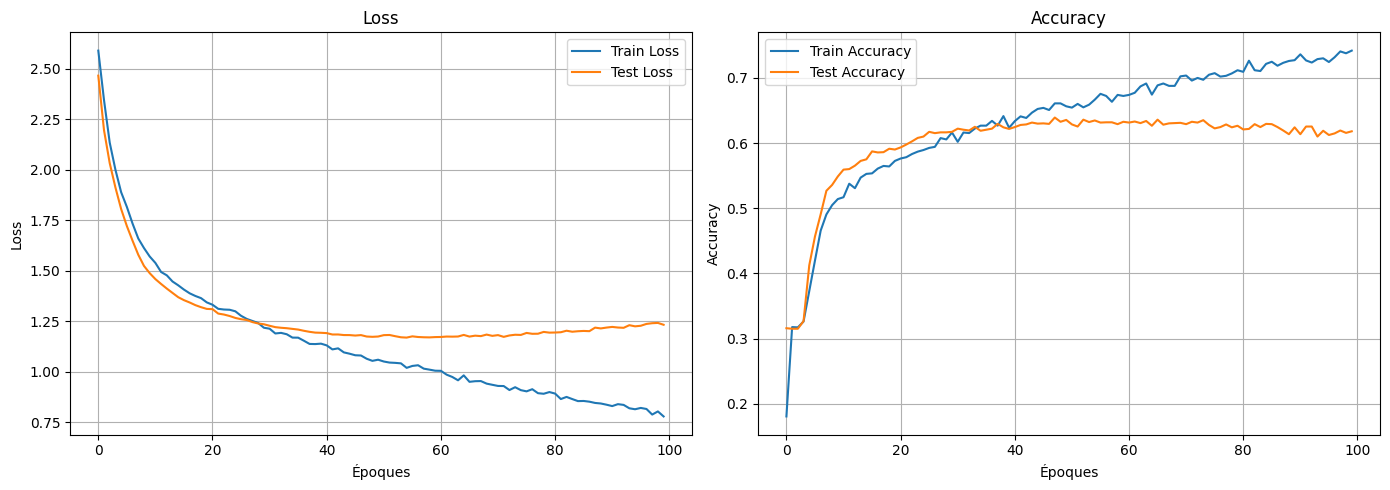

In [10]:
# Courbes d'entraînement CNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['test_loss'], label='Test Loss')
ax1.set(title='Loss', xlabel='Époques', ylabel='Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Accuracy')
ax2.plot(history['test_acc'], label='Test Accuracy')
ax2.set(title='Accuracy', xlabel='Époques', ylabel='Accuracy')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## Mantis Foundation Model

In [11]:
from mantis.architecture import Mantis8M
from mantis.trainer import MantisTrainer
from mantis.adapters import LinearChannelCombiner

# Preprocessing Mantis : pas de normalisation (Mantis le fait en interne), juste NaN -> 0
X_train_m = np.nan_to_num(X_train_raw, nan=0.0).transpose(0, 2, 1)  # (2459, 6, 36)
X_test_m = np.nan_to_num(X_test_raw, nan=0.0).transpose(0, 2, 1)    # (2466, 6, 36)

# Resize à 128 (doit être multiple de 32)
def resize(X, size=128):
    X_tensor = torch.tensor(X, dtype=torch.float)
    return F.interpolate(X_tensor, size=size, mode='linear', align_corners=False).numpy()

X_train_m = resize(X_train_m)
X_test_m = resize(X_test_m)
print(f'Format Mantis: {X_train_m.shape}')

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Format Mantis: (2459, 6, 128)


### Zero-shot ("Frozen backbone + linear classifier")

In [12]:
network_zs = Mantis8M(device=str(device))
network_zs = network_zs.from_pretrained('paris-noah/Mantis-8M')

model_zs = MantisTrainer(device=str(device), network=network_zs)
Z_train = model_zs.transform(X_train_m)
Z_test = model_zs.transform(X_test_m)

clf = RidgeClassifierCV()
clf.fit(Z_train, y_train)
y_pred_zs = clf.predict(Z_test)

zs_acc = accuracy_score(y_test, y_pred_zs)
zs_f1_mac = f1_score(y_test, y_pred_zs, average='macro')
zs_f1_w   = f1_score(y_test, y_pred_zs, average='weighted')

print(f'Mantis Zero-shot Accuracy:    {zs_acc:.4f}')
print(f'Mantis Zero-shot F1 Macro:    {zs_f1_mac:.4f}')
print(f'Mantis Zero-shot F1 Weighted: {zs_f1_w:.4f}')

Mantis Zero-shot Accuracy:    0.5787
Mantis Zero-shot F1 Macro:    0.4556
Mantis Zero-shot F1 Weighted: 0.5623


### Fine-tuning (full)

In [13]:
network_ft = Mantis8M(device=str(device))
network_ft = network_ft.from_pretrained('paris-noah/Mantis-8M')

model_ft = MantisTrainer(device=str(device), network=network_ft)

model_ft.fit(
    X_train_m, y_train,
    num_epochs=20,
    fine_tuning_type='full'
)

y_pred_ft = model_ft.predict(X_test_m)
ft_acc = accuracy_score(y_test, y_pred_ft)
print(f'Mantis Fine-tuned Accuracy: {ft_acc:.4f}')

Epoch 19: Train Loss 0.5033: 100%|██████████| 20/20 [03:37<00:00, 10.85s/it]


Mantis Fine-tuned Accuracy: 0.7084


In [14]:
print('--- Classification Report (Mantis Fine-tuned) ---')
print(classification_report(y_test, y_pred_ft, target_names=le.classes_))

--- Classification Report (Mantis Fine-tuned) ---
              precision    recall  f1-score   support

          15       0.69      0.53      0.60       124
          16       0.97      0.94      0.95       270
          42       0.55      0.59      0.57       382
          52       0.00      0.00      0.00        63
          53       1.00      0.57      0.73         7
           6       0.63      0.34      0.44        35
          62       0.40      0.20      0.26       153
          64       0.00      0.00      0.00        24
          65       0.74      0.96      0.83       313
          67       0.67      0.06      0.11        68
          88       0.98      0.98      0.98       121
          90       0.67      0.84      0.75       777
          92       0.90      0.92      0.91        77
          95       0.62      0.25      0.36        52

    accuracy                           0.71      2466
   macro avg       0.63      0.51      0.54      2466
weighted avg       0.68      0


## Récapitulatif

In [15]:
cnn_acc = max(history['test_acc'])

print(f'CNN Baseline:         {cnn_acc:.4f}')
print(f'Mantis Zero-shot:     {zs_acc:.4f}')
print(f'Mantis Fine-tuned:    {ft_acc:.4f}')

CNN Baseline:         0.6391
Mantis Zero-shot:     0.5787
Mantis Fine-tuned:    0.7084


### 3 seed average (mantis fine tuned full)

In [16]:
seeds = [42, 123, 456]
results_mantis = {'accuracy': [], 'f1_macro': [], 'f1_weighted': []}

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    network_ft = Mantis8M(device=str(device))
    network_ft = network_ft.from_pretrained('paris-noah/Mantis-8M')
    model_ft = MantisTrainer(device=str(device), network=network_ft)
    
    model_ft.fit(
        X_train_m, y_train,
        num_epochs=20,
        fine_tuning_type='full'
    )
    
    y_pred = model_ft.predict(X_test_m)
    
    acc = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    f1_w = f1_score(y_test, y_pred, average='weighted')
    
    results_mantis['accuracy'].append(acc)
    results_mantis['f1_macro'].append(f1_m)
    results_mantis['f1_weighted'].append(f1_w)
    
    print(f'Seed {seed}: Acc={acc:.4f} | F1 macro={f1_m:.4f} | F1 weighted={f1_w:.4f}')

print('\n--- Mantis Fine-tuned (moyenne ± std sur 3 seeds) ---')
for metric, values in results_mantis.items():
    print(f'{metric:15s}: {np.mean(values):.4f} ± {np.std(values):.4f}')

Epoch 6: Train Loss 1.0714:  35%|███▌      | 7/20 [01:13<02:15, 10.42s/it]

Epoch 19: Train Loss 0.4893: 100%|██████████| 20/20 [03:27<00:00, 10.38s/it]


Seed 42: Acc=0.6959 | F1 macro=0.5305 | F1 weighted=0.6672


Epoch 19: Train Loss 0.5128: 100%|██████████| 20/20 [03:25<00:00, 10.29s/it]


Seed 123: Acc=0.7036 | F1 macro=0.5212 | F1 weighted=0.6698


Epoch 19: Train Loss 0.5240: 100%|██████████| 20/20 [03:25<00:00, 10.28s/it]


Seed 456: Acc=0.7072 | F1 macro=0.5322 | F1 weighted=0.6751

--- Mantis Fine-tuned (moyenne ± std sur 3 seeds) ---
accuracy       : 0.7022 ± 0.0047
f1_macro       : 0.5280 ± 0.0049
f1_weighted    : 0.6707 ± 0.0033


On bat le baseline mais le f1 score reste moyen (on prédit surtout les classes dominantes dans le dataset)

### Seeing which classes are well classified 

In [17]:
X_train_m = np.nan_to_num(X_train_raw, nan=0.0).transpose(0, 2, 1)  # (2459, 6, 36)
X_test_m = np.nan_to_num(X_test_raw, nan=0.0).transpose(0, 2, 1)    # (2466, 6, 36)

# Resize à 128 (doit être multiple de 32)
def resize(X, size=128):
    X_tensor = torch.tensor(X, dtype=torch.float)
    return F.interpolate(X_tensor, size=size, mode='linear', align_corners=False).numpy()

X_train_m = resize(X_train_m)
X_test_m = resize(X_test_m)
print(f'Format Mantis: {X_train_m.shape}')

torch.manual_seed(123)
np.random.seed(123)

network_ft = Mantis8M(device=str(device))
network_ft = network_ft.from_pretrained('paris-noah/Mantis-8M')
model_ft = MantisTrainer(device=str(device), network=network_ft)

model_ft.fit(
    X_train_m, y_train,
    num_epochs=20,
    fine_tuning_type='full'
)

y_pred = model_ft.predict(X_test_m)
ft_acc = accuracy_score(y_test, y_pred)
print(f'Mantis Fine-tuned Accuracy: {ft_acc:.4f}')


Format Mantis: (2459, 6, 128)


Epoch 3: Train Loss 1.6675:  20%|██        | 4/20 [00:41<02:44, 10.26s/it]

Epoch 19: Train Loss 0.5128: 100%|██████████| 20/20 [03:25<00:00, 10.26s/it]


Mantis Fine-tuned Accuracy: 0.7036


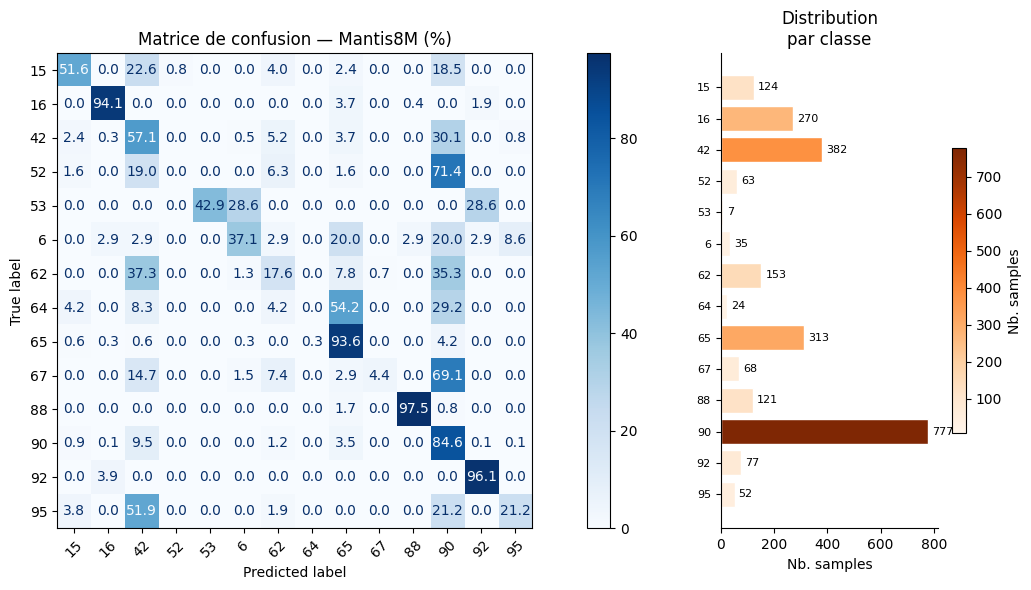

In [18]:
y_test_arr = le.inverse_transform(np.array(y_test))
y_pred_arr = le.inverse_transform(np.array(y_pred))
labels = sorted(np.unique(y_test_arr))

# --- Confusion matrix in % ---
cm = confusion_matrix(y_test_arr, y_pred_arr, labels=labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-wise %

# --- Class distribution ---
counts = np.array([np.sum(y_test_arr == l) for l in labels])

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          gridspec_kw={'width_ratios': [4, 1]})

# LEFT: confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=labels)
disp.plot(ax=axes[0], cmap='Blues', colorbar=True, values_format='.1f')
axes[0].set_title('Matrice de confusion — Mantis8M (%)')
axes[0].tick_params(axis='x', rotation=45)

# RIGHT: class distribution bar (horizontal, one cell per label)
norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
cmap = plt.cm.Oranges
colors = [cmap(norm(c)) for c in counts]

bars = axes[1].barh(
    y=np.arange(len(labels)),
    width=counts,
    color=colors,
    edgecolor='white',
    height=0.8
)

# Annotate each bar with count
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_width() + counts.max() * 0.02, bar.get_y() + bar.get_height() / 2,
                 str(count), va='center', ha='left', fontsize=8)

axes[1].set_yticks(np.arange(len(labels)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_xlabel('Nb. samples')
axes[1].set_title('Distribution\npar classe')
axes[1].invert_yaxis()  # match label order with confusion matrix
axes[1].spines[['top', 'right']].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axes[1], label='Nb. samples', shrink=0.6)

plt.tight_layout()
plt.savefig('confusion_matrix_mantis.png', dpi=150)
plt.show()